# Kapitel 13 - Lösungen

In [1]:
BeispielDaten=[[9,2,3],[9,9,9],[7,0,5],[8,4,4],
              [9,3,2],[7,9,8],[5,1,1],[7,2,3]]

In [2]:
# Aufgabe 1
import math, random
def korrel(p:list,q:list): # Korrelation
    n=len(p)
    pm=1/n*sum(p); qm=1/n*sum(q)
    cov=1/n*sum([(p[i]-pm)*(q[i]-qm) for i in range(n)])
    varp=1/n*sum([(p[i]-pm)**2 for i in range(n)])
    varq=1/n*sum([(q[i]-qm)**2 for i in range(n)])
    varq=max(varq,1e-5)  
    varp=max(varp,1e-5)  
    return cov/(math.sqrt(varp)*math.sqrt(varq))
def abstand(p:list,q:list)->float: 
   return 1-korrel(p,q)
def MP(daten:list,fallback=[])->list:
    if len(daten)==0: # Leere Daten haben kein Zentrum, wähle zufällig
        daten=[fallback]
    dim=len(daten[0]) # Dimension der einzelnen Vektoren     
    ergebnis=[0]*dim  # Null-Vektor der Dimension dim
    for i in range(dim): # für jede Dimension werden         
        for punkt in daten: # die Eintraege aller Daten              
            ergebnis[i]+=punkt[i]  # addiert     
    return [x/len(daten) for x in ergebnis]
# Alles andere kann bleiben wie gehabt.
# Im Ergebnis sieht man eine deutlich andere Strukur: Das Abstandsmaß mit korrel 
# bewertet nur die Richtung der Vektoren, nicht ihre Länge. Das ist zB Vorteilhaft,
# wenn man die Zahlen, die einen Fall chaktersieren sehr unterschiedliche Größenordnungen
# haben, etwa Schuhgrößen und Körpergrößen in m. Dann dominiert Ähnllichkeit der Schuhgröße

In [3]:
def kCluster(daten:list,k:int):
    n=len(daten)
    clusterVon=[i%k for i in range(n)] # Willkürliche Startzuordnung
    def PktvClus(j:int)->list: # j ist Cluster-Nummer
        return [daten[i] for i in range(n) if clusterVon[i]==j] 
    geändert=True     
    while geändert:
        geändert=False
        zentren=[MP(PktvClus(j),fallback=random.choice(daten)) for j in range(k)]         
        for i in range(n): # Punkte den Zentren zuordnen
            punkt=daten[i]             
            optimal=0 # Nummer des besten Zentrums 
            for c in range(1,k):
                if (abstand(zentren[c],punkt)<abstand(zentren[optimal],punkt) ):
                    optimal=c        
            if not(clusterVon[i]==optimal):
                geändert=True             
                clusterVon[i]=optimal     
    return [PktvClus(j) for j in range(k)] 
kCluster(BeispielDaten,3)

[[[9, 2, 3], [9, 9, 9], [7, 2, 3]],
 [[8, 4, 4], [9, 3, 2], [7, 9, 8], [5, 1, 1]],
 [[7, 0, 5]]]

In [4]:
def WCSS(clusters:list)->float:
    fehlersumme=0.0     
    for c in clusters:
        m=MP(c)
        for p in c: 
            fehlersumme+=abstand(p,m)
    return fehlersumme
def BCSS(daten:list,clusters:list)->float:
    bcss=0.0     
    for c in clusters:
        bcss+=len(c)*abstand(MP(c),MP(daten))
    return bcss
def R2(daten:list,clusters:list)->float:
    bcss=BCSS(daten,clusters)
    wcss=WCSS(clusters)
    return bcss/(wcss+bcss)
for k in range(2,5):
    print(k," Cluster: R2=",R2(BeispielDaten,kCluster(BeispielDaten,k)))
# Die Ergebnisse zeigen, dass bei der Abstandsmessung über die Korrelation 4 Cluster nötig erscheinen

2  Cluster: R2= 0.08076222485648268
3  Cluster: R2= 0.10872033297088403
4  Cluster: R2= 0.686281213755416


In [5]:
# Aufgabe 2
import csv
daten = []
with open('iris.csv', 'r', encoding='utf-8-sig') as datei:
    kopfzeile=next(datei)
    for zeile in csv.reader(datei):
        daten.append([float(zeile[i]) for i in range(len(zeile)-1)])
print("n=",len(daten))
for k in range(1,6):
    print(k," Cluster: R2=",R2(daten,kCluster(daten,k)))

n= 150
1  Cluster: R2= 0.0
2  Cluster: R2= 0.9148415840734446
3  Cluster: R2= 0.9619926599754688
4  Cluster: R2= 0.9208662602424328
5  Cluster: R2= 0.9702319059453516


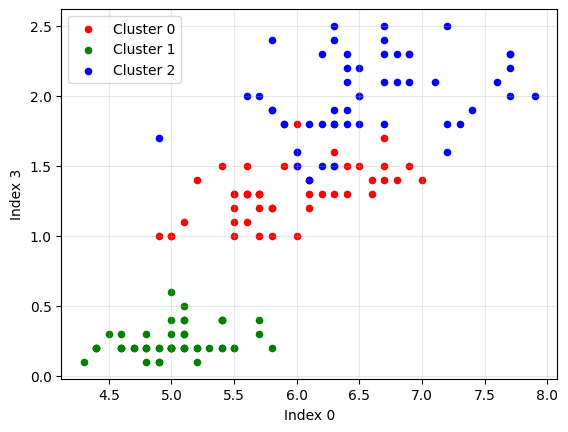

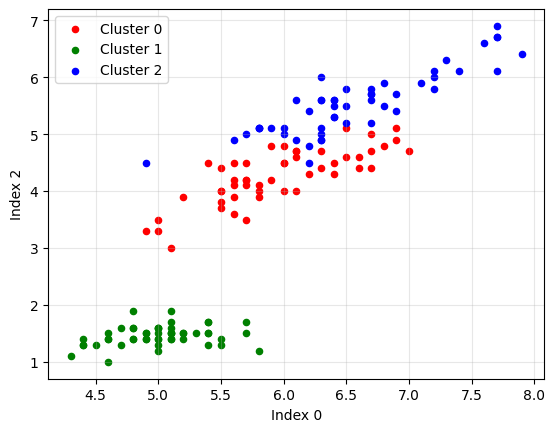

In [6]:
import matplotlib.pyplot as plt
def plotCData(cdata, ix, iy, colors=None, markersize=20):
    """
    cdata: Liste von Clustern, jeder Cluster ist eine Liste von Punkten (Listen)
    ix, iy: Indizes für x- bzw. y-Koordinate innerhalb eines Punkts
    colors: Liste von Farben (eine pro Cluster), z.B. ["red","green","blue"]
    """
    if colors is None:
        colors = [None] * len(cdata)  # matplotlib nimmt dann Default-Farben
    for j, cluster in enumerate(cdata):
        if len(cluster) == 0:
            continue
        xs = [p[ix] for p in cluster]
        ys = [p[iy] for p in cluster]
        plt.scatter(xs, ys, s=markersize, c=colors[j % len(colors)], label=f"Cluster {j}")
    plt.xlabel(f"Index {ix}")
    plt.ylabel(f"Index {iy}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
plotCData(kCluster(daten,3), 0, 3, ["red", "green", "blue"])
plotCData(kCluster(daten,3), 0, 2, ["red", "green", "blue"])